In [2]:
from pathlib import Path
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import tables_io
import matplotlib.pyplot as plt 
%matplotlib inline 


In [3]:

widegalaxy=tables_io.read('/project/kicp/chto/roman-sompz/hlwas_cosmos_260120_UM_2026_01_22.parquet')
widegalaxy_assignment=tables_io.read('/project/kicp/chto/roman-sompz/test/widedata_wide_assignment.hdf5')
tomotbinwide = tables_io.read("/project/kicp/chto/roman-sompz/test/tomo_bins_wide.hdf5")
widebinning = tomotbinwide['tomo_bins_wide'][:,0][widegalaxy_assignment['cells']]

column_list None


In [4]:
wzsample = tables_io.read("/project/kicp/chto/roman-sompz/test/photoz_realizations.hdf5")

In [5]:
wzsamples = []
for keys in wzsample.keys():
    wzsamples.append(wzsample[keys])
wzsamples = np.concatenate(wzsamples, axis=0)    

In [6]:
import h5py
tomotbinwide_ref  = h5py.File("/project/kicp/chto/roman-sompz/test/FINAL_NZ.hdf5",'r')

In [7]:
redshiftcol='specz'
zbinsc = tomotbinwide_ref['meta/xvals'][:][0]
#zbinsc = 0.5*(zbins[1:]+zbins[:-1])


In [8]:
len(zbinsc)

101

6349
9222
8830
16284
6814


(0.0, 3.2)

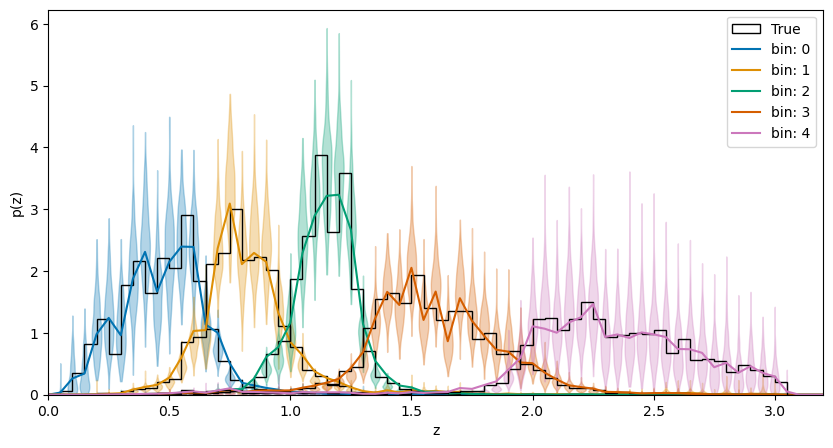

In [10]:
import seaborn as sns
colors = sns.color_palette('colorblind')
fig = plt.figure(figsize=(10,5))
for i in range(5):
    if i==0:
        name="True"
    else:
        name=None
    plt.hist(np.array(widegalaxy[redshiftcol])[widebinning==i], density=True, histtype="step", bins=zbinsc, color='k', label=name)
    print(len(np.array(widegalaxy[redshiftcol])[widebinning==i]))
    plt.plot(zbinsc,tomotbinwide_ref['data/yvals'][:][i], "-", label="bin: "+str(i), c=colors[i])
    violin_parts = plt.violinplot(wzsamples[:,i,:]/(zbinsc[1]-zbinsc[0]), positions=zbinsc, widths=0.04, showmeans=False, showmedians=False, showextrema=False, quantiles = None)
    for pc in violin_parts['bodies']:
        pc.set_facecolor(colors[i])
        pc.set_edgecolor(colors[i])
plt.legend()
plt.xlabel("z")
plt.ylabel("p(z)")
plt.xlim(0,3.2)
